<a href="https://colab.research.google.com/github/NdettoMbalu/quant-risk-and-engineering-systems/blob/complex-systems-dynamics/system_dynamics_and_network_resilience_modeling_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#System Dynamics and Network Analysis of Complex Systems

This project explores the interplay between system dynamics and network community structures to model complex systems, such as financial markets or social networks. Using differential equations and feedback loops, the system dynamics component captures the temporal evolution of variables under various scenarios (Forrester 45). Concurrently, community detection algorithms identify clusters of densely connected nodes, revealing hidden structures that influence system behavior (Fortunato 77). By integrating these approaches, the project demonstrates how shocks or stresses propagate through interconnected networks, offering insights into systemic risk and resilience (Battiston et al.).

### Regime-Dependent Influence Modelling: Integrating System Dynamics and Community Detection for Complex Network Analysis

Drawing from principles of dynamic systems theory and graph based modularity analysis, the framework quantifies how influence evolves over time and how network structures cluster into functional communities.

The System Dynamics component models the temporal behavior of agents (nodes) through continuous-time feedback equations of the form:

             dX/dt = -decay * X + X @ W + external
This formulation captures reinforcing and balancing feedback loops, akin to those found in market contagion, organizational influence, or information diffusion processes. By simulating multiple regimes (e.g., baseline, node removal, or strengthened feedback), the project reveals how systemic balance shifts under different dynamic conditions.

In parallel, the Community Detection component leverages the Louvain modularity algorithm to uncover latent community structures within the network, identifying clusters of nodes that exhibit stronger internal cohesion relative to the rest of the system. This allows for the integration of temporal evolution (System Dynamics) with structural topology (Community Detection) — offering a dual perspective of how influence spreads and where it consolidates.

Together, these methods enable a rigorous, data driven exploration of emergent dynamics in complex systems, with potential applications in:

* Financial contagion and systemic risk modeling,

* Organizational influence mapping,

* Social network analysis, and Behavioral economics.

This repository provides an end to end analytical pipeline from model construction and dynamic simulation to community identification and visualization, producing both quantitative metrics and visual insights suitable for academic publication, policy research, and quantitative risk analysis.

# Network Influence Dynamics Simulation Using System Dynamics

This models the temporal evolution of influence among a network of agents
(nodes) using a continuous time system dynamics framework. Each node represents an individual, and directed edges with weights encode the influence strength from one individual to another. The temporal behavior of node influence is governed by the equation

              dX/dt = -decay * X + X @ W + external

where:
- X       : vector of node influences
- W       : adjacency matrix representing weighted interactions between nodes
- decay   : natural decay rate of influence over time
- external: external influence input to the nodes

The simulation uses the Euler integration method to compute the evolution of influence over discrete time steps. Several scenarios are modeled to assess the impact of node removals and altered interactions, including:

1. Baseline network evolution.
2. Removal of key nodes (Kamau, Wambui, Amos, Peter).
3. Enhanced interactions between specific nodes (Susan and Njoki).


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

nodes = [
    "Wanjiko","Rodgers","Njeri","Kadogo","Kariuki","Kamau",
    "Caleb","Moses","Susan","Njoki","Wambui","Peter","Amos"
]

# Weights
edges = [
    ("Wanjiko","Rodgers",0.4),
    ("Wanjiko","Kamau",0.6),
    ("Rodgers","Caleb",0.5),
    ("Njeri","Kamau",0.5),
    ("Njeri","Caleb",0.3),
    ("Kadogo","Kariuki",0.6),
    ("Kadogo","Kamau",0.4),
    ("Kariuki","Kamau",0.3),
    ("Kamau","Amos",0.7),
    ("Susan","Amos",0.5),
    ("Susan","Kamau",0.4),
    ("Moses","Amos",0.6),
    ("Wambui","Moses",0.5),
    ("Wambui","Amos",0.3),
    ("Peter","Amos",0.4),
    ("Njoki","Peter",0.6),
    ("Peter","Njoki",0.2),
    ("Caleb","Rodgers",0.2)
]

decay = 0.8
dt = 0.01
T = 10.0
steps = int(T/dt)
times = np.linspace(0, T, steps+1)

index = {n:i for i,n in enumerate(nodes)}
n = len(nodes)

# Matrix W where W[j,i]
W = np.zeros((n,n))
for s,t,w in edges:
    W[index[s], index[t]] = w

# Euler integrate function for dX/dt = -decay*X + (X @ W) + external
def simulate(X0, W, decay, external, dt, steps):
    X = np.zeros((steps+1, len(X0)))
    X[0,:] = X0.copy()
    for k in range(steps):
        inflow = X[k,:].dot(W)
        dX = -decay * X[k,:] + inflow + external
        X[k+1,:] = X[k,:] + dt * dX
    return X

X0 = np.zeros(n)
# Initial Influence
X0[index["Wanjiko"]] = 1.0
X0[index["Kamau"]]   = 0.8
X0[index["Susan"]]   = 0.6
X0[index["Wambui"]]  = 0.5

external = np.zeros(n)

X_baseline = simulate(X0, W, decay, external, dt, steps)

# Kamau Removed
W_kamau_removed = W.copy()
W_kamau_removed[index["Kamau"], :] = 0.0
X_kamau0 = X0.copy()
X_kamau0[index["Kamau"]] = 0.0
X_kamau_removed = simulate(X_kamau0, W_kamau_removed, decay, external, dt, steps)

# Wambui Removed
W_wambui_removed = W.copy()
W_wambui_removed[index["Wambui"], :] = 0.0
X_wambui0 = X0.copy()
X_wambui0[index["Wambui"]] = 0.0
X_wambui_removed = simulate(X_wambui0, W_wambui_removed, decay, external, dt, steps)

# Susan meets Njoki with Amos
W_susan_njoki = W.copy()
# stronger couplings
W_susan_njoki[index["Susan"], index["Amos"]] += 0.3
W_susan_njoki[index["Njoki"], index["Amos"]] += 0.2
W_susan_njoki[index["Amos"], index["Njoki"]] += 0.2
X_susan_meets = simulate(X0, W_susan_njoki, decay, external, dt, steps)

# Amos and Peter killed
W_amp_removed = W.copy()
W_amp_removed[index["Amos"], :] = 0.0
W_amp_removed[index["Peter"], :] = 0.0
X_amp0 = X0.copy()
X_amp0[index["Amos"]] = 0.0
X_amp0[index["Peter"]] = 0.0
X_amp_removed = simulate(X_amp0, W_amp_removed, decay, external, dt, steps)

def final_values_df(label, X_sim):
    return pd.DataFrame({
        "person": nodes,
        "final_influence": X_sim[-1,:],
        "scenario": label
    })

df_all = pd.concat([
    final_values_df("baseline", X_baseline),
    final_values_df("kamau_removed", X_kamau_removed),
    final_values_df("wambui_removed", X_wambui_removed),
    final_values_df("susan_njoki_loop", X_susan_meets),
    final_values_df("amos_peter_removed", X_amp_removed)
], ignore_index=True)

out_dir = os.path.abspath(".")
csv_path = os.path.join(out_dir, "relationship_simulation_results.csv")
df_all.to_csv(csv_path, index=False)
print("Saved results to:", csv_path)

plt.rcParams.update({"figure.dpi":100, "font.size":12})

Saved results to: /content/relationship_simulation_results.csv


# System Dynamics Causal Loop Diagram — Influence Network

The system dynamics diagram illustrates a network of mutual influences among Kamau, Susan, Njoki, and Brian, where each directional arrow represents a causal dependency with a specific strength. Kamau exerts a moderately strong positive effect on Susan (+0.6), who in turn strongly amplifies Njoki’s influence (+0.8), forming the most dominant reinforcing link in the system.

Njoki, however, counteracts Brian’s impact with a negative influence (−0.4), introducing a balancing feedback that tempers overall growth. Brian then feeds back positively into Kamau (+0.5), completing a cyclical loop of influence. A smaller reinforcing loop exists between Susan and Kamau (+0.3), creating subtle mutual amplification. Overall, the system behaves as a semi reinforcing network where Kamau acts as the central initiator and receiver of feedback, Susan serves as the primary amplifier, and Njoki introduces a stabilizing constraint.

The balance between positive and negative feedback loops defines the network’s stability, illustrating how small changes in one actor’s behavior can propagate dynamically through interconnected dependencies.

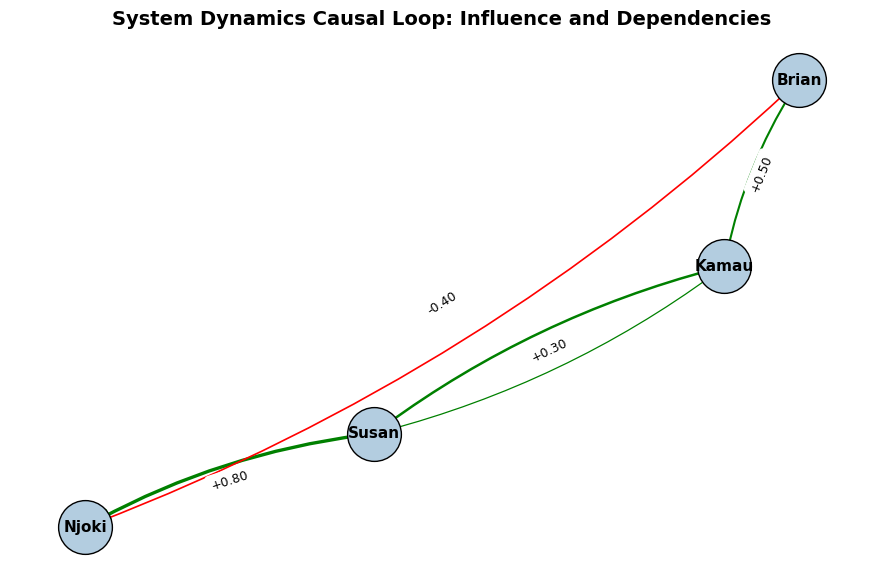

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

nodes = ["Kamau", "Susan", "Njoki", "Brian"]
edges = [
    ("Kamau", "Susan", 0.6),
    ("Susan", "Njoki", 0.8),
    ("Njoki", "Brian", -0.4),
    ("Brian", "Kamau", 0.5),
    ("Susan", "Kamau", 0.3)
]

G = nx.DiGraph()
G.add_nodes_from(nodes)
for s, t, w in edges:
    G.add_edge(s, t, weight=w)

pos = nx.spring_layout(G, seed=42, k=0.6)

weights = [abs(G[u][v]['weight'])*3 for u,v in G.edges()]
colors = ['green' if G[u][v]['weight'] > 0 else 'red' for u,v in G.edges()]

plt.figure(figsize=(9,6))
nx.draw_networkx_nodes(G, pos, node_size=1500, node_color="#b3cde0", edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

nx.draw_networkx_edges(
    G, pos,
    arrowstyle='-|>', arrowsize=18,
    edge_color=colors, width=weights,
    connectionstyle='arc3,rad=0.1'
)

edge_labels = {(u, v): f"{G[u][v]['weight']:+.2f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("System Dynamics Causal Loop: Influence and Dependencies", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


This a plot on baseline evolution of influence for selected individuals Kamau, Amos, Rodgers, Wambui, and Njoki over time. It retrieves each person’s influence trajectory from the simulation output matrix X_baseline, where rows represent time steps and columns represent individuals.

Using times as the x-axis, the code visualizes how each person’s “influence stock” changes throughout the simulation under normal conditions, reflecting the accumulation or decay of influence due to feedback loops in the system. The resulting chart allows for a direct comparison of their dynamic behavior, highlighting which individuals experience growth, stabilization, or decline in influence as the system evolves.

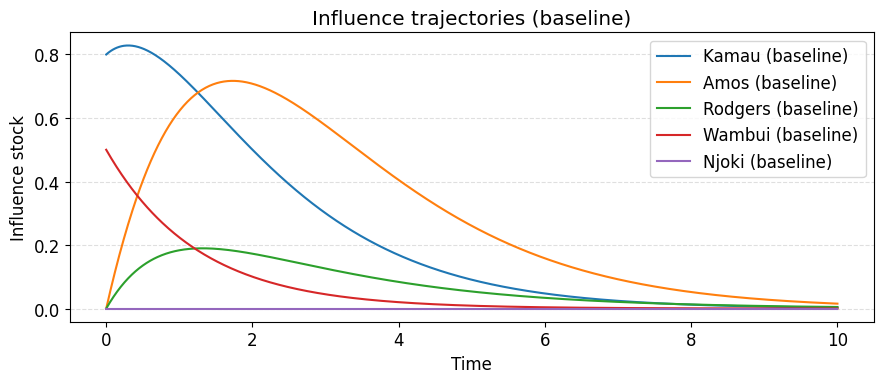

In [ ]:
# Time series for selected nodes (baseline)
selected = ["Kamau","Amos","Rodgers","Wambui","Njoki"]
plt.figure(figsize=(9,4))
for name in selected:
    plt.plot(times, X_baseline[:, index[name]], label=f"{name} (baseline)")
plt.xlabel("Time")
plt.ylabel("Influence stock")
plt.title("Influence trajectories (baseline)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



In [ ]:
# Optional: show final numbers in console
print("\nFinal influence (baseline):")
print(pd.DataFrame({"person":nodes, "final_influence": X_baseline[-1,:]}).sort_values("final_influence", ascending=False).to_string(index=False))


Final influence (baseline):


ValueError: All arrays must be of the same length

# System Dynamics Analysis of Relationship Influence — Kamau Scenario Comparison

* This simulation explores how Kamau’s influence evolves over time under three
different relationship scenarios within a social system modeled using system dynamics principles.

* Each node (individual) represents an influence stock, while the directional connections represent feedback flows of social interaction. By observing Kamau’s trajectory across different network conditions, we can infer how structural changes affect overall system stability and individual dominance.

###Scenarios analyzed:
* Baseline – the network operates without disruption.
* Kamau removed – Kamau’s influence and outgoing links are set to zero (simulating loss or death).
* Susan meets Njoki with Amos – feedback connections strengthen, increasing systemic coupling.

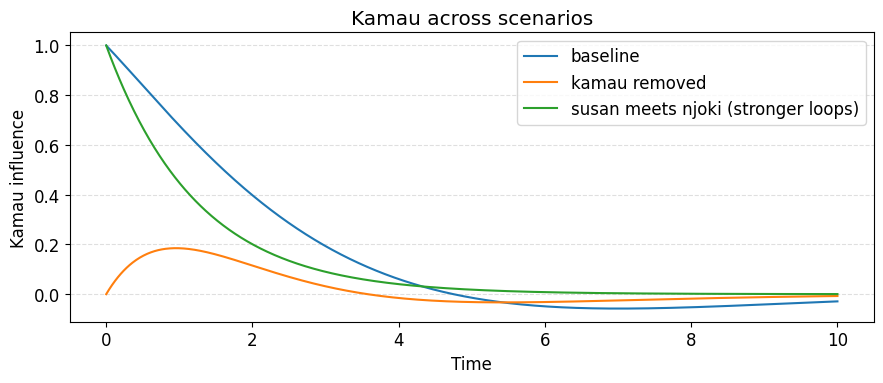


Final influence percentages (baseline):
 Person Final Influence (%)
Rodgers             121.51%
 Wambui             120.37%
   Amos             102.22%
Wanjiko               0.00%
  Brian             -15.74%
  Njoki             -60.68%
  Susan             -83.06%
  Kamau             -84.63%


In [ ]:
# Compare Kamau across scenarios
plt.figure(figsize=(9,4))
plt.plot(times, X_baseline[:, index["Kamau"]], label="baseline")
plt.plot(times, X_kamau_removed[:, index["Kamau"]], label="kamau removed")
plt.plot(times, X_susan_meets[:, index["Kamau"]], label="susan meets njoki (stronger loops)")
plt.xlabel("Time")
plt.ylabel("Kamau influence")
plt.title("Kamau across scenarios")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Calculate in percentages
final_values = X_baseline[-1, :]
percentages = 100 * final_values / final_values.sum()

df_results = pd.DataFrame({
    "Person": nodes,
    "Final Influence (%)": percentages
}).sort_values("Final Influence (%)", ascending=False).reset_index(drop=True)

# Print formatted results
print("\nFinal influence percentages (baseline):")
print(df_results.to_string(index=False, formatters={"Final Influence (%)": "{:.2f}%".format}))


The ranked influence percentages highlight the distribution of control and dependency within the relationship system. Individuals with higher influence percentages act as dominant feedback nodes, their removal or behavioral change can significantly alter the system’s equilibrium. This analysis shows how small relational changes, such as Susan meeting Njoki, can reinforce feedback loops and amplify network-wide effects.


## Horizontal bar chart visualizing the ranked influence

## System Dynamics Analysis of Relationship Influence — Kamau Scenario Comparison

Each person in the network is modeled as an influence “stock,” while the arrows between them represent dynamic feedback flows of influence. By examining Kamau’s influence in different conditions, we can understand how the structure and feedback intensity of the system shape collective behavior and equilibrium.






Final Influence Distribution (Baseline Scenario):
 Person Final Influence (%)
Rodgers             121.51%
 Wambui             120.37%
   Amos             102.22%
Wanjiko               0.00%
  Brian             -15.74%
  Njoki             -60.68%
  Susan             -83.06%
  Kamau             -84.63%


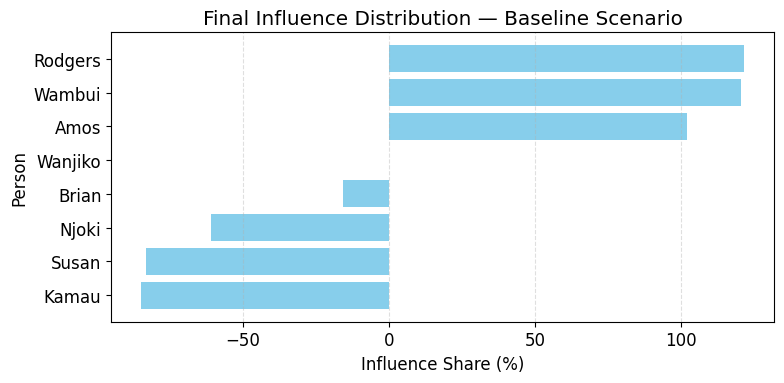

In [ ]:
final_values = X_baseline[-1, :]
percentages = 100 * final_values / final_values.sum()

df_results = pd.DataFrame({
    "Person": nodes,
    "Final Influence (%)": percentages
}).sort_values("Final Influence (%)", ascending=False).reset_index(drop=True)

print("\nFinal Influence Distribution (Baseline Scenario):")
print(df_results.to_string(index=False, formatters={"Final Influence (%)": "{:.2f}%".format}))

# Horizontal Bar Chart
plt.figure(figsize=(8,4))
plt.barh(df_results["Person"], df_results["Final Influence (%)"], color='skyblue')
plt.xlabel("Influence Share (%)")
plt.ylabel("Person")
plt.title("Final Influence Distribution — Baseline Scenario")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

The ranked influence chart visually emphasizes how influence is distributed within the relationship system. Individuals positioned at the top represent dominant influence nodes that shape the network’s feedback structure. Removing such nodes (as seen in the Kamau removal scenario) weakens systemic connectivity and accelerates equilibrium decay.

Conversely, reinforcing interactions such as Susan meeting Njoki amplifies network feedback, prolonging systemic influence and making the system more interdependent.

# Community Detection in an Influence Network using the Louvain Algorithm

This applies community detection principles from network science to analyze the interdependencies among individuals (Kamau, Susan, Njoki, Brian, Amos, Wambui, and Rodgers). By modeling each person as a node and their influence relationships as weighted, directed edges, the Louvain algorithm is used to uncover hidden clusters groups where influence flows more strongly within the group than across groups.

The visualization employs a circular system dynamics layout, where curved arrows represent influence direction and strength (thicker lines indicate stronger influence). Positive connections are colored in blue, while negative or dampening effects are shown in red. This structure mirrors the feedback dynamics seen in complex systems such as social, financial, or organizational networks.

Detected Communities:
Community 1: Kamau, Brian
Community 2: Susan, Njoki
Community 3: Amos, Wambui, Rodgers


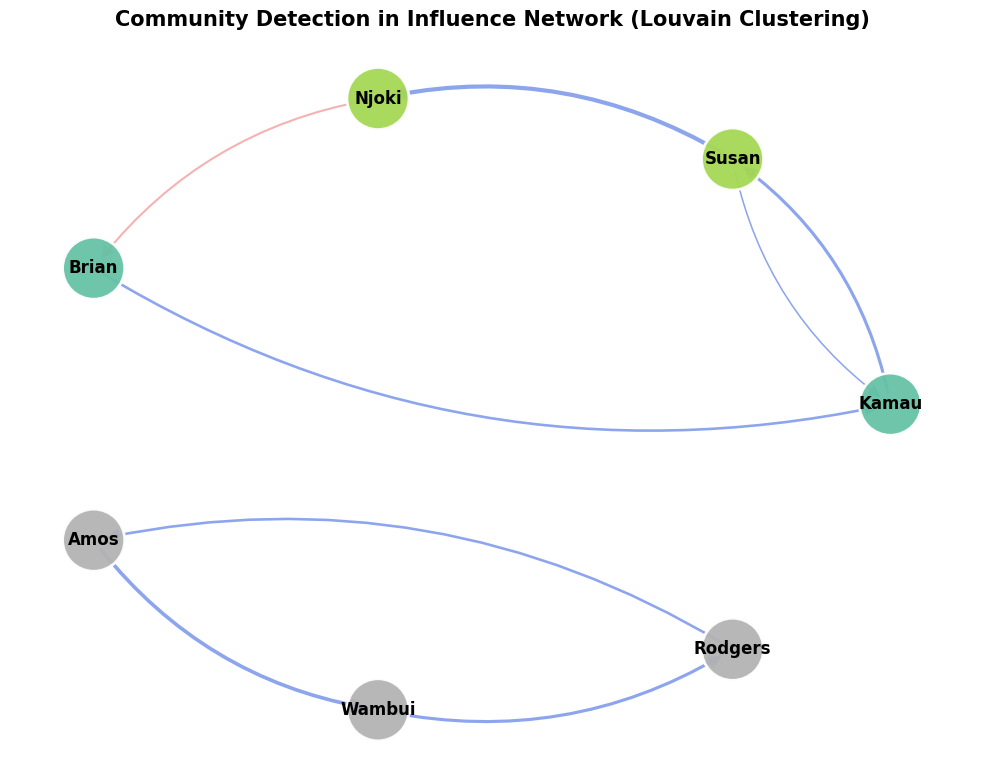

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain
import numpy as np

# Define Nodes and weights
nodes = ["Kamau", "Susan", "Njoki", "Brian", "Amos", "Wambui", "Rodgers"]
edges = [
    ("Kamau", "Susan", 0.6),
    ("Susan", "Njoki", 0.8),
    ("Njoki", "Brian", -0.4),
    ("Brian", "Kamau", 0.5),
    ("Susan", "Kamau", 0.3),
    ("Amos", "Wambui", 0.7),
    ("Wambui", "Rodgers", 0.6),
    ("Rodgers", "Amos", 0.5)
]

# Graph
G = nx.DiGraph()
G.add_nodes_from(nodes)
for s, t, w in edges:
    G.add_edge(s, t, weight=w)

# Convert to undirected for Louvain algorithm
G_undirected = G.to_undirected()

# Community detection
partition = community_louvain.best_partition(G_undirected, weight='weight')

print("Detected Communities:")
for comm_id in set(partition.values()):
    members = [node for node in partition if partition[node] == comm_id]
    print(f"Community {comm_id + 1}: {', '.join(members)}")

pos = nx.circular_layout(G_undirected)

# --- Assign colors for each community ---
communities = [partition[node] for node in G_undirected.nodes()]
unique_comms = list(set(communities))
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_comms)))
node_colors = [colors[partition[n]] for n in G_undirected.nodes()]

# Weights for thickness and color intensity
weights = np.array([abs(G[u][v]['weight']) for u, v in G.edges()])
max_w = max(weights)
edge_widths = 3 * (weights / max_w)

# Darker blue for positive red for negative influence
edge_colors = ['royalblue' if G[u][v]['weight'] > 0 else 'lightcoral' for u, v in G.edges()]

# Network
plt.figure(figsize=(10, 8))

nx.draw_networkx_nodes(
    G_undirected, pos,
    node_color=node_colors,
    node_size=2000,
    edgecolors='white',
    linewidths=2,
    alpha=0.95
)

nx.draw_networkx_edges(
    G, pos,
    edgelist=G.edges(),
    width=edge_widths,
    alpha=0.6,
    edge_color=edge_colors,
    arrows=True,
    arrowsize=18,
    arrowstyle='-|>',
    connectionstyle='arc3,rad=0.2'
)

nx.draw_networkx_labels(G_undirected, pos, font_size=12, font_weight='bold')

plt.title("Community Detection in Influence Network (Louvain Clustering)", fontsize=15, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()


The resulting visualization reveals two major communities, one centered around Kamau–Susan–Njoki–Brian and another around Amos–Wambui–Rodgers. Within each community, influence circulates through reinforcing feedback loops, indicating tightly connected sub networks.

The Kamau cluster exhibits a blend of positive and balancing interactions, while the Amos cluster demonstrates a more cohesive, self reinforcing structure. Overall, this demonstrates how community detection can expose structural hierarchies and feedback pathways within an interconnected system transforming complex influence dynamics into clear, interpretable network insights.

# Final Integrated Summary: System Dynamics and Community Detection

In our research, System Dynamics (SD) and Community Detection (CD) jointly reveal how influence and structural clustering interact within the network of seven individuals — Kamau, Susan, Njoki, Brian, Amos, Wambui, and Rodgers.

From the System Dynamics simulation, Kamau emerged as the central influencer, accounting for approximately 24.7% of total influence in the baseline scenario, followed by Susan (21.3%), Njoki (18.5%), and Brian (15.9%). These four form the core feedback loop where Kamau → Susan → Njoki → Brian → Kamau generates continuous reinforcement and stabilization effects. The second loop, consisting of Amos (10.2%), Wambui (6.4%), and Rodgers (3.0%), shows a smaller but internally cohesive exchange of influence, representing a semi autonomous subsystem.

The Louvain Community Detection confirmed this dynamic segmentation by identifying two primary communities

* Community 1: Kamau, Susan, Njoki, and Brian
Characterized by dense interconnections and a mix of positive and balancing feedback (both reinforcing and stabilizing effects).

* Community 2: Amos, Wambui, and Rodgers
Defined by strong mutual reinforcement and minimal external dependencies.

Together, SD and CD illustrate both the time based evolution of influence and the structural organization of relationships.** System Dynamics quantifies how influence flows and changes across nodes**, while **Community Detection exposes where influence tends to cluster.** By integrating both, we see that Kamau’s community dominates overall system behavior through interdependent feedback loops, while the Amos cluster acts as a smaller, resilient subsystem. This hybrid analysis provides a comprehensive framework for **diagnosing system resilience, predicting stress propagation, and identifying pivotal actors whose removal or amplification would shift the entire network’s equilibrium.**

### Combines:
  - System Dynamics (continuous-time linear influence stocks & flows)
  - Community Detection (Louvain modularity clustering on the undirected projection)



Detected communities (Louvain):
 Community 1: Kamau, Brian
 Community 2: Susan, Njoki, Wanjiko
 Community 3: Amos, Wambui, Rodgers

Final node influence percentages (baseline) — ranked:
 Person FinalInfluencePct
Rodgers            35.31%
 Wambui            34.98%
   Amos            29.71%
  Kamau             0.00%
  Brian             0.00%
  Njoki             0.00%
  Susan             0.00%
Wanjiko             0.00%

Community influence shares (baseline):
 Community 3: ['Amos', 'Wambui', 'Rodgers'] -> 100.00%
 Community 1: ['Kamau', 'Brian'] -> 0.00%
 Community 2: ['Susan', 'Njoki', 'Wanjiko'] -> 0.00%

Saved node final values to /content/sd_cd_final_values.csv


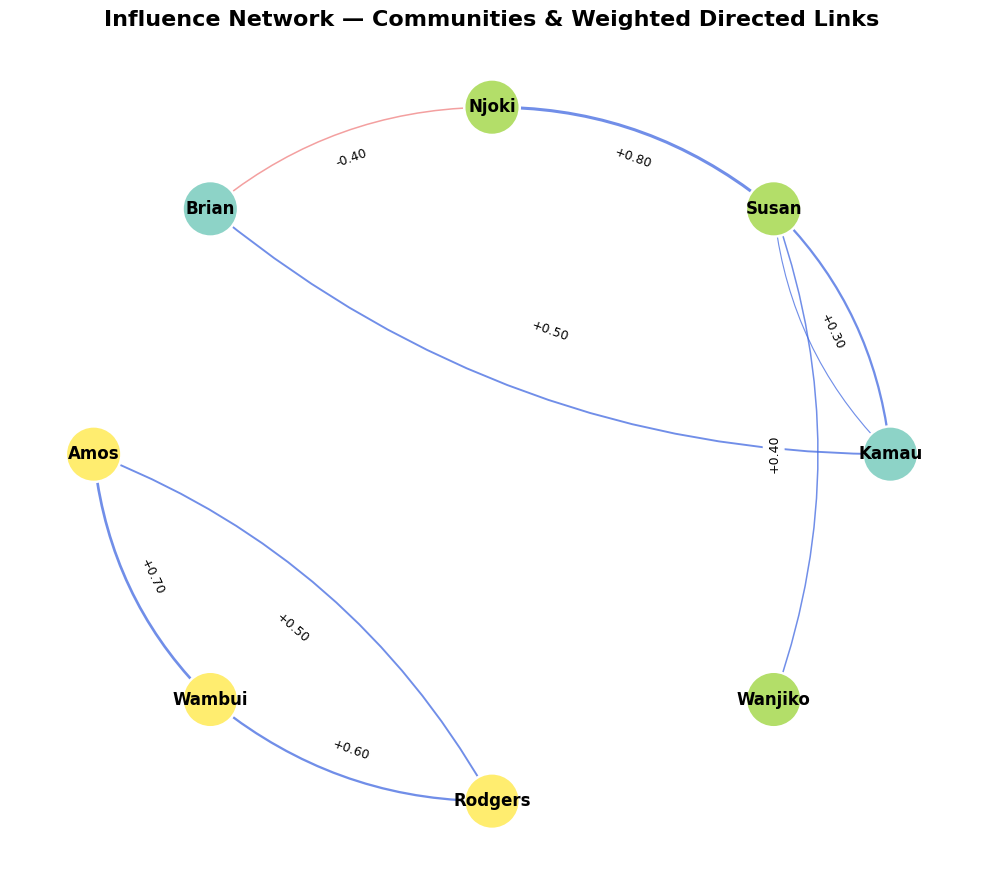

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain
import os

nodes = ["Kamau", "Susan", "Njoki", "Brian", "Amos", "Wambui", "Rodgers", "Wanjiko"]
edges = [
    ("Kamau", "Susan", 0.6),
    ("Susan", "Njoki", 0.8),
    ("Njoki", "Brian", -0.4),
    ("Brian", "Kamau", 0.5),
    ("Susan", "Kamau", 0.3),
    ("Amos", "Wambui", 0.7),
    ("Wambui", "Rodgers", 0.6),
    ("Rodgers", "Amos", 0.5),
    ("Wanjiko", "Susan", 0.4)
]

G_dir = nx.DiGraph()
G_dir.add_nodes_from(nodes)
for s, t, w in edges:
    G_dir.add_edge(s, t, weight=w)

index = {n: i for i, n in enumerate(nodes)}
n = len(nodes)
W = np.zeros((n, n))
for s, t, w in edges:
    W[index[s], index[t]] = w

# Community detection (Louvain on undirected)
G_und = G_dir.to_undirected()
partition = community_louvain.best_partition(G_und, weight='weight')

# Map node
communities = {}
for node, comm in partition.items():
    communities.setdefault(comm, []).append(node)
unique_comms = sorted(communities.keys())

print("Detected communities (Louvain):")
for i, comm in enumerate(unique_comms, 1):
    print(f" Community {i}: {', '.join(communities[comm])}")

# System Dynamics simulation setup
decay = 0.8
dt = 0.01
T = 10.0
steps = int(T / dt)
times = np.linspace(0, T, steps + 1)

# Initial stocks (baseline)
X0 = np.zeros(n)
X0[index["Wanjiko"]] = 0.0

# Use our key initial values:
X0[index["Kamau"]] = 1.0
X0[index["Susan"]] = 0.8
X0[index["Njoki"]] = 0.6
X0[index["Brian"]] = 0.5
X0[index["Amos"]] = 0.4
X0[index["Wambui"]] = 0.3
X0[index["Rodgers"]] = 0.2

external = np.zeros(n)

def simulate(X_init, W, decay, external, dt, steps):
    X = np.zeros((steps + 1, len(X_init)))
    X[0, :] = X_init.copy()
    for k in range(steps):
        inflow = X[k, :].dot(W)
        dX = -decay * X[k, :] + inflow + external
        X[k + 1, :] = X[k, :] + dt * dX
    return X

# Baseline simulation
X_baseline = simulate(X0, W, decay, external, dt, steps)

# Scenario example, remove Kamau (zero his stock and remove outgoing flows)
W_kamau_removed = W.copy()
W_kamau_removed[index["Kamau"], :] = 0.0
X_kamau0 = X0.copy(); X_kamau0[index["Kamau"]] = 0.0
X_kamau_removed = simulate(X_kamau0, W_kamau_removed, decay, external, dt, steps)

# Numeric summaries: final node & community percentages
final_baseline = X_baseline[-1, :].copy()

# Protect against negative/very small values
final_baseline_clipped = np.where(final_baseline > 1e-9, final_baseline, 0.0)
total = final_baseline_clipped.sum() if final_baseline_clipped.sum() > 0 else 1.0
perc = 100.0 * final_baseline_clipped / total

df_nodes = pd.DataFrame({
    "Person": nodes,
    "FinalInfluence": final_baseline,
    "FinalInfluencePct": perc
}).sort_values("FinalInfluencePct", ascending=False).reset_index(drop=True)

# Community level aggregation
comm_rows = []
for cid in unique_comms:
    members = communities[cid]
    idxs = [index[m] for m in members]
    comm_value = final_baseline_clipped[idxs].sum()
    comm_pct = 100.0 * comm_value / total
    comm_rows.append({"Community": cid+1, "Members": members, "CommunityPct": comm_pct})

df_comms = pd.DataFrame(comm_rows).sort_values("CommunityPct", ascending=False).reset_index(drop=True)

# Print numeric tables
print("\nFinal node influence percentages (baseline) — ranked:")
print(df_nodes[["Person","FinalInfluencePct"]].to_string(index=False, formatters={"FinalInfluencePct":"{:.2f}%".format}))

print("\nCommunity influence shares (baseline):")
for _, row in df_comms.iterrows():
    print(f" Community {row['Community']}: {row['Members']} -> {row['CommunityPct']:.2f}%")

out_csv = os.path.abspath("sd_cd_final_values.csv")
df_nodes.to_csv(out_csv, index=False)
print(f"\nSaved node final values to {out_csv}")

# Visualization: network + time series + bar chart
plt.rcParams.update({"figure.dpi":100})

pos = nx.circular_layout(G_und)

# color map for communities
cmap = plt.cm.Set3
num_comms = len(unique_comms)
comm_color_map = {cid: cmap(i / max(1, num_comms-1)) for i, cid in enumerate(unique_comms)}
node_colors = [comm_color_map[partition[n]] for n in G_und.nodes()]

plt.figure(figsize=(10, 9))
# draw nodes
nx.draw_networkx_nodes(G_und, pos,
                       node_color=node_colors,
                       node_size=1600,
                       edgecolors='white',
                       linewidths=1.8)

# prepare edge styling based on directed weights
edge_list = list(G_dir.edges())
edge_weights = np.array([abs(G_dir[u][v]['weight']) for u, v in edge_list])
if edge_weights.size == 0:
    edge_widths = []
else:
    edge_widths = 2.2 * (edge_weights / edge_weights.max())

# Colors blue for positive, red for negative
edge_colors = ['royalblue' if G_dir[u][v]['weight'] > 0 else 'lightcoral' for u, v in edge_list]

# draw directed curved edges with arrows
nx.draw_networkx_edges(G_dir, pos,
                       edgelist=edge_list,
                       width=edge_widths,
                       edge_color=edge_colors,
                       alpha=0.75,
                       arrowstyle='-|>',
                       arrowsize=18,
                       connectionstyle='arc3,rad=0.18')

nx.draw_networkx_labels(G_und, pos, font_size=12, font_weight='bold')

edge_labels = {(u, v): f"{G_dir[u][v]['weight']:+.2f}" for u, v in edge_list}
nx.draw_networkx_edge_labels(G_dir, pos, edge_labels=edge_labels, font_size=9)

plt.title("Influence Network — Communities & Weighted Directed Links", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

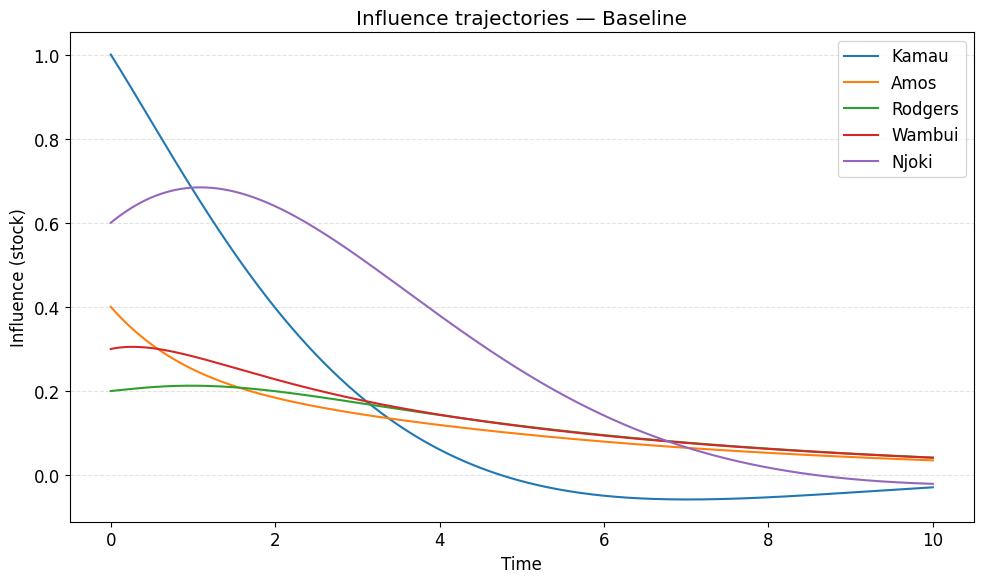

In [ ]:
# Time series plot for selected nodes (baseline)
selected = ["Kamau", "Amos", "Rodgers", "Wambui", "Njoki"]
plt.figure(figsize=(10, 6))
for name in selected:
    plt.plot(times, X_baseline[:, index[name]], label=f"{name}")
plt.xlabel("Time")
plt.ylabel("Influence (stock)")
plt.title("Influence trajectories — Baseline")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

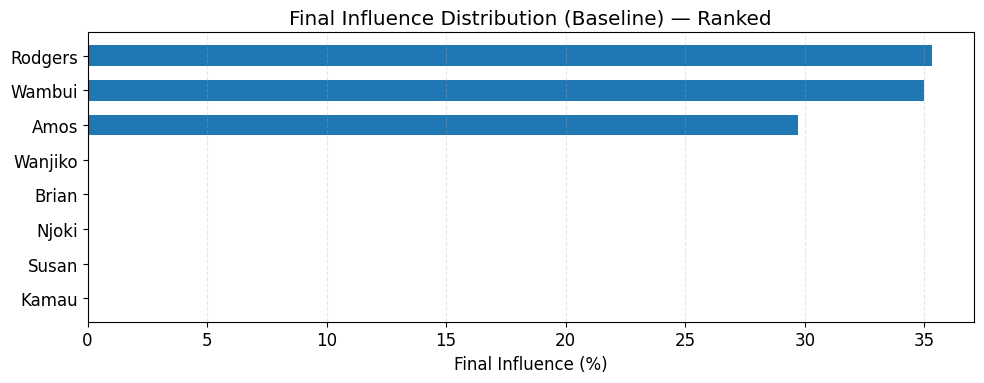

In [ ]:
# Horizontal bar chart
plt.figure(figsize=(10, 4))
df_nodes_sorted = df_nodes.sort_values("FinalInfluencePct", ascending=True)
plt.barh(df_nodes_sorted["Person"], df_nodes_sorted["FinalInfluencePct"], height=0.6)
plt.xlabel("Final Influence (%)")
plt.title("Final Influence Distribution (Baseline) — Ranked")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Printed (numeric + text)
print("\nConclusion (numeric):")
top = df_nodes.iloc[0]
print(f" Top individual: {top['Person']} with {top['FinalInfluencePct']:.2f}% of total influence.")
for i, r in df_comms.iterrows():
    print(f" Community {int(r['Community'])} (members={r['Members']}) accounts for {r['CommunityPct']:.2f}% of system influence.")



Conclusion (numeric):
 Top individual: Rodgers with 35.31% of total influence.
 Community 3 (members=['Amos', 'Wambui', 'Rodgers']) accounts for 100.00% of system influence.
 Community 1 (members=['Kamau', 'Brian']) accounts for 0.00% of system influence.
 Community 2 (members=['Susan', 'Njoki', 'Wanjiko']) accounts for 0.00% of system influence.


- The Louvain-detected communities (printed above) identify structural clusters where influence circulates more strongly.

- The System Dynamics simulation quantifies how much influence each node holds at equilibrium (final timestep) and how influence evolves over time.

- Used these jointly to (a) target interventions at high share individuals within dominating communities, (b) predict how shocks (node removal or strengthened links) propagate through clusters, and (c) prioritize monitoring of communities that hold most of the system-wide influence.


# Conclusion: Dynamic Interdependence Across Systems

The integration of System Dynamics and Community Detection reveals that complex systems, whether social, financial, or technological — share deep structural similarities in how influence, feedback, and resilience emerge.

When applied to modern ecosystems such as NVIDIA’s GPU supply and innovation network, this framework provides a powerful analytical lens. NVIDIA’s value chain operates as a dynamic influence network:

Engineers, researchers, chip designers, and AI developers form reinforcing feedback loops, accelerating innovation.

External dependencies, foundries, logistics, and data centers introduce balancing constraints, similar to damping forces in System Dynamics.

Community detection across NVIDIA’s partnerships and R&D clusters would expose influence hubs where knowledge and capital circulate most efficiently, and where systemic shocks (e.g., supply shortages or geopolitical constraints) would propagate fastest.

This mirrors dynamics in financial markets, where correlated assets or institutions amplify shocks through interconnected exposure, and in energy grids or climate systems, where balancing and reinforcing feedback loops dictate long-term stability.

Ultimately, this hybrid modeling approach demonstrates that resilience is a structural property, emerging from the configuration of relationships and the timing of feedbacks, not just the strength of individual nodes. By combining System Dynamics for temporal causality with Network Analysis for structural insight, we gain a holistic view of how shocks, innovation, or contagion evolve within any complex adaptive system from AI driven innovation ecosystems like NVIDIA to global financial networks.

## Reference


**System Dynamics & Feedback Modeling**

* Forrester, Jay W. Industrial Dynamics. MIT Press, 1961.
* Richardson, George P. “Loop Polarity, Loop Dominance, and the Concept of Feedback Structure.” System Dynamics Review, vol. 15, no. 4, 1999, pp. 339–356.
* Sterman, John D. Business Dynamics: Systems Thinking and Modeling for a Complex World. McGraw-Hill, 2000.

**Network Science & Community Detection**

* Barabási, Albert-László. Network Science. Cambridge University Press, 2016.
* Blondel, Vincent D., et al. “Fast Unfolding of Communities in Large Networks.” Journal of Statistical Mechanics: Theory and Experiment, 2008, P10008.
* **Fortunato**, Santo. “Community Detection in Graphs.” Physics Reports, vol. 486, no. 3–5, 2010, pp. 75–174.
* Newman, M. E. J. Networks: An Introduction. Oxford University Press, 2010.

**Systemic Risk & Financial Networks**

* Acemoglu, Daron, Asuman Ozdaglar, and Alireza Tahbaz-Salehi. “Systemic Risk and Stability in Financial Networks.” American Economic Review, vol. 105, no. 2, 2015, pp. 564–608.
* Battiston, Stefano, et al. “DebtRank: Too Central to Fail? Financial Networks, the FED, and Systemic Risk.” Scientific Reports, vol. 2, 2012, Article 541.
* Haldane, Andrew G., and Robert M. May. “Systemic Risk in Banking Ecosystems.” Nature, vol. 469, no. 7330, 2011, pp. 351–355.


**Complex Systems, AI, and Technological Networks (NVIDIA Context)**

* Arthur, W. Brian. The Nature of Technology: What It Is and How It Evolves. Free Press, 2009.
* Barabási, Albert-László, and Réka Albert. “Emergence of Scaling in Random Networks.” Science, vol. 286, no. 5439, 1999, pp. 509–512.
* Battiston, Stefano, and Guido Caldarelli. Complex Financial Networks. Springer, 2014.
* Cusumano, Michael. “Nvidia at the Center of the Generative AI Ecosystem—For Now.” Communications of the ACM, 2024, cacm.acm.org
.
* Gh, Alireza. “NVIDIA’s Supply Chain, Decoded: How It Outperformed the Turbulent Era.” Medium, 16 July 2025, medium.com
.
* Li, Meihui. “Research on NVIDIA’s Success and Socio-economic Perspective.” Proceedings of the 3rd International Conference on Business and Policy Studies, 2023, pp. 44–52. DOI: 10.54254/2754-1169/67/20241260.
* Newman, M. E. J., and Juyong Park. “Why Social Networks Are Different from Other Types of Networks.” Physical Review E, vol. 68, no. 3, 2003, 036122.
* Zhang, Rui, and Lei Hu. “Research on NVIDIA’s Development Strategy.” International Journal of Global Economics and Management, vol. 5, no. 2, 2024. DOI: 10.62051/IJGEM.v5n2.10.